## DLA CODE OF CONDUCT V2.0

This Code of Conduct defines the principles governing ethical, transparent, and responsible use of Large Language Models (LLMs), online resources, and peer collaboration in the Deep Learning Applications laboratories. This version of the Code of Conduct was refined via a brainstorming session with **ChatGPT Version 5.2** and subsequently adapted to reflect the specific requirements and values of the DLA laboratories. In that spirit, this Code itself models the transparency it expects from you.

***Our goal is not to restrict innovation, but to ensure integrity, accountability, and genuine learning.***

### 1. Transparency in the Use of LLMs and AI Tools

The use of LLMs and AI-assisted tools is permitted — *but it must be transparent*.

* **Explicit Disclosure:** Clearly state if and how LLMs (e.g., ChatGPT, Copilot, Claude, etc.) were used. This includes code generation, debugging, data analysis, experiment design, report writing, or conceptual clarification.
* **Description of Contribution:** Briefly describe what the tool contributed and how you modified, verified, or extended its output.
* **Acknowledgment of Limitations:** Recognize that LLM outputs may contain errors, biases, or non-optimal solutions. You are responsible for verifying correctness, appropriateness, and academic integrity.

***Using AI does not reduce your responsibility for the final result.***

### 2. Proper Attribution and Documentation

Deep learning builds on existing work — responsibly.

* **Attribution:** Properly cite all external resources, including: Code snippets, Tutorials, Documentation, Datasets, Pretrained models, Research papers, and AI-generated content.
* **Reproducibility:** Clearly document tools, libraries, model versions, hyperparameters, and experimental setups so that your work can be reproduced.
* **Clarity of Modifications:** If you adapt external code, explicitly indicate what you changed and why.

***Transparency is a sign of scientific maturity — not weakness.***

### 3. Collaboration and Individual Responsibility

Discussion is encouraged. Copying is not.

* **Collaborative Learning:** You are encouraged to discuss concepts, debugging strategies, and approaches with classmates.
* **Individual Submission:** Your submitted solution must reflect your own understanding and implementation.
* **No Direct Sharing of Solutions:** Do not share complete solutions, trained models, or reports. Do not submit another person's work — or AI-generated work — as your own without meaningful engagement and proper disclosure.

***If you cannot explain your submission, it is not your submission.***

### 4. Accountability and Academic Integrity

You are responsible for everything you submit. Failure to comply with these guidelines may result in review by the course examination commission and can lead to disciplinary measures in accordance with university regulations.

***Integrity is part of your training as a machine learning practitioner.***

### 5. The Spirit of This Code of Conduct

This course prepares you to work in a field where:

* Reproducibility matters
* Ethical considerations matter
* Transparency matters
* Responsible AI use matters

***The purpose of this Code of Conduct is not surveillance — it is professional formation.***

### TL;DR

Use AI; Don’t let AI use you; Be transparent; Cite everything; Do your own thinking.

***If you can’t explain it, you probably shouldn’t submit it.***

---
---

## Introduction

In this first laboratory we will see a few ways to exploit and adapt pre-trained models to solve new problems. We will start first by downloading and instantiating a new dataset and establishing a stable and reproducible baseline model based on a pre-trained CNN.

---

## Exercise 1 (Warmup): Exploratory Data Analysis and a Stable Baseline

For this laboratory we will work with [The German Traffic Sign Detection Benchmark](https://benchmark.ini.rub.de/) [1]. We will begin, not with *detection*, but with a simpler traffic sign *classification* problem. This has two advantages: (1) the images are *smaller* than in the detection benchmark; and (2) a wrapper for the GTSRB dataset is conveniently included in the `torchvision` library.  

[1] Houben S, Stallkamp J, Salmen J, Schlipsing M, Igel C. Detection of traffic signs in real-world images: The German Traffic Sign Detection Benchmark. In The 2013 International Joint Conference on Neural Networks (IJCNN), 2013.

### Exercise 1.1: Exploratory Data Analysis

A good best practice to adopt in all experimental deep learning projects is thorough *exploratory data analysis*. In this exercise you should instantiate the GTSRB Dataset, inspect some images, and do some statistical analysis of the distribution of data (and metadata). A goal here is to keep an eye out for anything that might be problematic in what is to come.



In [3]:
# Standard imports and aliases.
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.transforms.v2 as T     # Use transforms v2; much more efficient.
from torchvision.datasets import GTSRB
from torch.utils.data import random_split
import pandas as pd #To manage csv , xls ecc..
from torchvision.models import list_models, get_model
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch.nn as nn
import torch.optim as optim
import wandb
import copy
import matplotlib.patches as patches
import torchvision.ops as ops
from tqdm.notebook import tqdm
import torchvision.transforms.functional as F
from datasets import load_dataset

In [4]:
device= 'cuda' if torch.cuda.is_available() else "cpu"

print(f"Versione PyTorch: {torch.__version__}")
print(f"Versione CUDA interna: {torch.version.cuda}")
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device:{device}")

Versione PyTorch: 2.8.0
Versione CUDA interna: None
Device:mps


The function below serves to split the dataset in three sets applying a trasformation. Thats because, seeing the kaggle page of this dataset there are:
- Test
- Train
- Meta

In [20]:
def init_datasets(trasform_application=None):
    ds_test= GTSRB('_data/',split='test',transform=trasform_application ,download=True)
    ds_full_train= GTSRB('_data/',split='train', transform=trasform_application, download=True)
    
    #I will take the 25% of training set for the validation set
    train_size = int(len(ds_full_train)*0.75)
    val_size = len(ds_full_train) - train_size
    
    generator = torch.Generator().manual_seed(42)
    ds_train, ds_val = random_split(ds_full_train, [train_size, val_size], generator=generator)
    
    
    print(f"Train Full:\n{ len(ds_full_train)}")
    print(f"Total Images: {len(ds_full_train) + len(ds_test)}")
    print(f"Validation Set:\n {len(ds_val)}")
    print(f"Train Set:\n {len(ds_train)}")
    print(f"Test:\n {len(ds_test)}")
    return ds_train, ds_val, ds_test

As first consideration, we have downloaded the data GTSRB and there are two partition looking in the PyTorch documentation. The first one is the Test Dataset and has 12630 samples, meanwhile the train one has the double of samples.
Now, we can try to analyze how is composed the dataset.

In [21]:
#Looking for the shape of this structure.
transform1 = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

ds_train, ds_val, ds_test = init_datasets(trasform_application=transform1)

Train Full:
26640
Total Images: 39270
Validation Set:
 6660
Train Set:
 19980
Test:
 12630


In [58]:
def info_print(sample):
    print(f"Type of object: {type(sample)}\n")

    print(f"Elements in the object: {len(sample)}\n")
    
    print(f"Type of the first element: {type(sample[0])}, Type of the second element: {type(sample[1])}\n")
    
    print(f"First Element dimention:{sample[0].shape}")

    print(f"{sample[0]}\n")

    print(f"Label: {sample[1]}")
    

In [59]:
info_print(ds_train[0])

Type of object: <class 'tuple'>

Elements in the object: 2

Type of the first element: <class 'torchvision.tv_tensors._image.Image'>, Type of the second element: <class 'int'>

First Element dimention:torch.Size([3, 34, 32])
Image([[[0.8314, 0.8392, 0.8275,  ..., 0.5647, 0.4706, 0.4000],
        [0.8431, 0.8275, 0.8314,  ..., 0.3765, 0.3294, 0.3255],
        [0.8196, 0.8157, 0.8196,  ..., 0.4706, 0.4078, 0.3725],
        ...,
        [0.7333, 0.7333, 0.7373,  ..., 0.6510, 0.6196, 0.5843],
        [0.7216, 0.7255, 0.7333,  ..., 0.6431, 0.6275, 0.6392],
        [0.7294, 0.7216, 0.7294,  ..., 0.6941, 0.6941, 0.6549]],

       [[0.8431, 0.8549, 0.8510,  ..., 0.5725, 0.5020, 0.4353],
        [0.8549, 0.8431, 0.8510,  ..., 0.3765, 0.3529, 0.3529],
        [0.8353, 0.8314, 0.8392,  ..., 0.4667, 0.4275, 0.3922],
        ...,
        [0.7451, 0.7412, 0.7373,  ..., 0.6588, 0.6275, 0.5843],
        [0.7333, 0.7255, 0.7255,  ..., 0.6510, 0.6431, 0.6392],
        [0.7451, 0.7294, 0.7333,  ..., 0.70

The dataset is formed by 39270 tuple, each one has two fields:
- **data:**  is a tensor that has shape (C, H, W) where C=3 represents the RGB channels. Each channel contains a 2D matrix of size H × W, representing the pixel intensities of that color component. Therefore, the image is stored as three separate matrices corresponding to the Red, Green, and Blue channels.
  
- **label:** the class of the traffic sign in the image.



At this point, we can see all the image for all classes.

In [1]:
def visualize_all_classes(ds,num_cols):
    max_label = max(label for _, label in ds) + 1
    print(f"Max Class: {max_label}")
    
    image_per_label = {}
    labels = []

    for img, label in ds:
        if label not in image_per_label:
            image_per_label[label] = img
            labels.append(label)
        if len(image_per_label) == max_label:
            break
    rows= (max_label //num_cols) + 1 
    plt.figure(figsize=(15,10))

    for i, (label,img) in enumerate(sorted(image_per_label.items())):
        plt.subplot(rows, num_cols, i+1)

        if isinstance(img, torch.Tensor):
            img = img.permute(1, 2, 0).numpy()
            
        if img.min() < 0:
            img = np.clip(img, 0, 1)
        plt.imshow(img)
        plt.title(f"Label: {label}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [2]:
labels = visualize_all_classes(ds_train,8)

NameError: name 'ds_train' is not defined

With this function, we can see that the dataset has 43 categories of traffic signs.\
What we can analyse is if the dataset is bilanced or all the image have the same dimension. 

In [74]:
df_stats = pd.DataFrame([(cls, img.shape[1],img.shape[2]) for (img,cls) in ds_train], columns=["Class","Height", "Width"])

To better understand all the components of this lab, a DataFrame is a tabular data structure provided by the Pandas library. It can be thought of as similar to a CSV, SQL table, or Excel file.

This structure is useful for several tasks, including:

- Reading data from CSV, Excel, or JSON files
- Filtering rows
- Selecting specific columns
- Computing summary statistics using the .describe() method
- Sorting and grouping data

DataFrames are particularly important in machine learning because they allow us to easily preprocess data. For example, we can remove unnecessary features using the .drop() method and analyze the dataset more effectively.

In [76]:
df_stats["Aspect Rateo"]=df_stats["Width"] / df_stats["Height"]  
df_stats.describe()

,Class,Height,Width,Aspect Rateo
count,19980.000000,19980.0,19980.0,19980.0
mean,15.931031,64.0,64.0,1.0
std,12.029721,0.0,0.0,0.0
min,0.000000,64.0,64.0,1.0
25%,6.000000,64.0,64.0,1.0
50%,12.000000,64.0,64.0,1.0
75%,25.000000,64.0,64.0,1.0
max,42.000000,64.0,64.0,1.0


The Class column ranges from 0 to 42, with an average value of about 15.93, indicating multiple categories distributed across the dataset.

For image dimensions, the average Height is 50.34 pixels and the average Width is 50.93 pixels, with standard deviations around 23–24 pixels, meaning there is a moderate variation in image sizes. The smallest images are 25×25 pixels, while the largest reach 225×243 pixels.

The Aspect Ratio has a mean of 1.01 and a median of 1.00, showing that most images are nearly square. The relatively small standard deviation (0.07) confirms that shapes are generally consistent, with only a few elongated images.

array([[<Axes: title={'center': 'Class'}>,
        <Axes: title={'center': 'Height'}>],
       [<Axes: title={'center': 'Width'}>,
        <Axes: title={'center': 'Aspect Rateo'}>]], dtype=object)

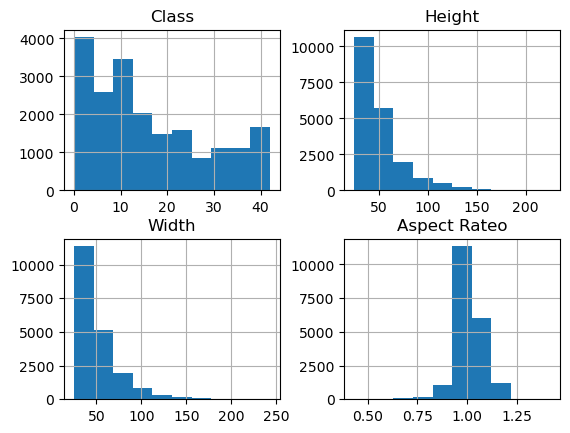

In [65]:
df_stats.to_csv("dataframe.csv",index=False)
df_stats.hist()

In these graphs, we can observe that:

- The images do not all have the same size, so we need to apply cropping to make them uniform in dimensions.

- A large portion of the dataset consists of images with dimensions of 50×50 pixels.

- The classes are not perfectly balanced; we could apply some techniques to address this issue.

All the images in the dataset are processed using transformations.
Moreover, as shown by the describe() output, the classes are not balanced.
During training, this may cause some classes to be recognized better than others.

Using the function below, we calculate the number of sample for each class, from these counts we calculate the frequence and we create a tensor that it is gonna passed to the WeightedRandomSampler.
PyTorch's WeightedRandomSampler is a tool designed to handle highly imbalanced datasets without physically altering or deleting data.
Instead of drawing samples uniformly at random—which naturally favors majority classes—it assigns a statistical weight to each sample, typically the inverse of its class frequency. This gives rare images a much higher probability of being selected. By combining these weights with the replacement=True parameter, the sampler dynamically oversamples minority classes, frequently re-drawing rare images during the same training epoch.

In [104]:
def create_sampler(ds):
    lbls = np.zeros(44)
    for item in ds:
        lbls[item[1]] += 1
    class_weights = 1.0 / (lbls + 1e-6)

    sample_weights = []
    for item in ds:
        label = item[1]
        peso_di_questa_immagine = class_weights[label]
        sample_weights.append(peso_di_questa_immagine)


    sample_weights = torch.tensor(sample_weights, dtype=torch.float)


    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights), # Pesca tante immagini quante ne ha il dataset
        replacement=True                 # Permette di pescare più volte le classi rare
    )
    
    print("Sampler created!")
    return sampler

In [105]:
sampler = create_sampler(ds_train)

Sampler created!


Train Full:
26640
Total Images: 39270
Validation Set:
 6660
Train Set:
 19980
Test:
 12630
Max Class: 43


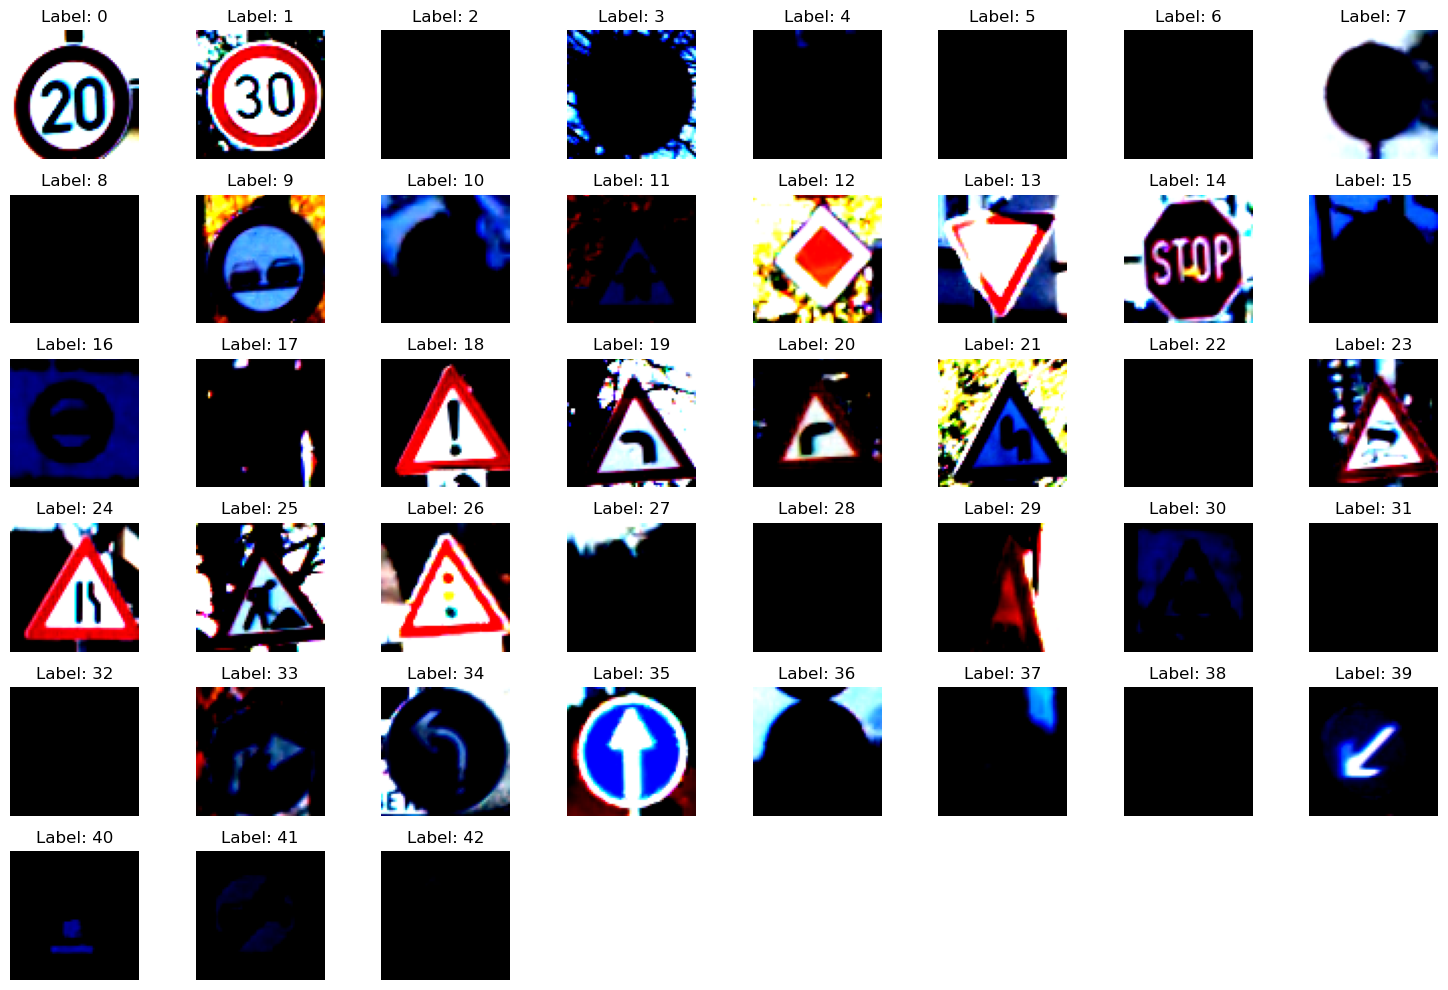

In [106]:
#See in the resnet or CNN used.
final_transform = T.Compose([T.Resize(70),T.RandomCrop((64,64)),T.ToTensor(), T.Normalize(mean=[0.485,0.456, 0.406], std=[0.229,0.224,0.225])])
#In this case, we applies the trasformation on the dataset
ds_train, ds_val, ds_test = init_datasets(final_transform)
#Visualize the trasformation.
visualize_all_classes(ds_train,8)

### Analysis

Deep Learning is very much an *experimental* discipline. Experiments are *nothing* without analysis and interpretation. Be sure to **always** stop and analyze the results of preliminary explorations. Note anything significant and -- importantly -- anything that is going to be relevant for what comes next.

So... In this Markdown cell you should collect and report (using, for the love of God, the *rich markup capabilities of Markdown*) any relevant findings you have made before proceding.

**Important Warning**: This is the **one and only** time I will remind you of the need to provide *analysis* and interpretation of your experimental methodology and results. The responsibility is *yours* to include it elsewhere.


---
### Exercise 1.2: A Stable and Reproducible Baseline

In this exercise you should implement code to use a pretrained network as a *feature extractor* that, instead of *classifying* images in input, should return the *feature representation* from the last layer of the pretrained model before the classifier. These features, extracted from the train set, should be used to train a *classical* model for classification (e.g. an SVM, a Nearest Neighbor, or a Linear Discriminant classifier from Scikit-learn). Evaluate the performance of this baseline model on the features extracted from the test set.

In [107]:
list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [115]:

#Create a DataLoader
def init_dataloaders(ds_train, ds_val, ds_test,sampler ,batchsize=1024):
    
    dl_train = DataLoader(ds_train, batch_size=batchsize,sampler=sampler)
    dl_val = DataLoader(ds_val, batch_size=batchsize, shuffle = False)
    dl_test = DataLoader(ds_test, batch_size= batchsize, shuffle=False)
    return dl_train, dl_val, dl_test

#The weights are of a training on 1K Dataset ImageNet
model= get_model("resnet50", weights='DEFAULT').to(device)

In [109]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

Before modifying the model, it is useful to understand how it is composed.  
We can recall the formula for computing the output dimension after a convolution:

$
O = \left\lfloor \frac{I + 2P - K}{S} \right\rfloor + 1
$

Where:
- **O**: Output dimension  
- **I**: Input dimension 
- **P**: Padding  
- **K**: Kernel size   
- **S**: Stride  
- $\lfloor \cdot \rfloor$: Floor function (rounding down)  

Using Gemini to calculate the dimentions of each output feature starting by 224$\times$224.

The model uses **Bottleneck blocks** instead of basic blocks.  
The distribution of these blocks across the four layers is:

**3, 4, 6, 3**

This configuration uniquely identifies the **ResNet-50** architecture.
The input image passes through an initial preprocessing stage:

- **conv1**: A large $7 \times 7$ convolution with stride 2  
  - Reduces spatial resolution  
  - Extracts low-level features

- **bn1 & relu**:  
  - Batch Normalization stabilizes training and making sure they don't get too big
  - ReLU introduces non-linearity  

- **maxpool**: A $3 \times 3$ max-pooling with stride 2  

At the end of this stage, the input resolution is reduced by a factor of 4:  
$
224 \times 224 \rightarrow 56 \times 56
$

Unlike simple blocks, the **Bottleneck design** improves computational efficiency using three convolutional layers:

- **$1 \times 1$ Conv (Reduction)**  
  Reduces the number of channels ( 256 → 64)

- **$3 \times 3$ Conv**  
  Performs spatial feature extraction  

- **$1 \times 1$ Conv (Expansion)**  
  Expands channels back (e.g., 64 → 256)



The network is divided into four stages that progressively extract higher-level features:

| Stage   | Blocks | Input Channels | Output Channels | Feature Map Resolution |
|--------|--------|----------------|-----------------|------------------------|
| Layer1 | 3      | 64             | 256             | High (e.g., 56×56)     |
| Layer2 | 4      | 256            | 512             | Medium (e.g., 28×28)   |
| Layer3 | 6      | 512            | 1024            | Low (e.g., 14×14)      |
| Layer4 | 3      | 1024           | 2048            | Very Low (e.g., 7×7)   |

- **Layer 3** is the deepest part of the network (6 blocks), where complex semantic features are learned  
- **Layer 4** produces the final high-dimensional representation  


At the end of the convolutional backbone there is the classification head:

- **avgpool (AdaptiveAvgPool2d)**  
  Performs **Global Average Pooling**  
  $
  7 \times 7 \times 2048 \rightarrow 1 \times 1 \times 2048
  $

- **fc (Linear layer)**  
  Maps the 2048 features to **1000 output classes** (ImageNet)

In [110]:
model.fc= nn.Identity()
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

Using the function below, we can show an embedding of the model. Obv the output will not represent something semantically important. But we can see the activation of the models.

In [127]:
def visualize_output_embedding(embedding):
    if isinstance(embedding, torch.Tensor):
        emb_array = embedding.detach().cpu().numpy().squeeze()
    else:
        emb_array = np.squeeze(embedding) 

    
    #assert emb_array.shape[0] == 2048, f"Attenzione: l'embedding ha dimensione {emb_array.shape}, ci servono esattamente 512 elementi!"
    
    emb_image = emb_array.reshape(40, 25)
    
    plt.figure(figsize=(5, 5)) 
    
    # Puoi cambiare 'cmap' con 'hot', 'magma' o 'cividis' se preferisci altri colori
    plt.imshow(emb_image, cmap='viridis', aspect='auto', interpolation='nearest') 
    
    plt.colorbar(label='Livello di Attivazione (Valore numerico)')
    plt.title("Visualizzazione dell'Embedding 512D (Griglia 16x32)", fontsize=14)
    plt.axis('off') # Nascondiamo gli assi X e Y perché non sono coordinate spaziali
    plt.tight_layout()
    plt.show()

In [120]:
def create_dataset_features(dataloader):
    outputs_features = []
    classes_features = []
    
    for imgs, cls in tqdm(dataloader):
        imgs = imgs.to(device)
        
        with torch.no_grad():
            # Fondamentale: spostiamo le feature calcolate sulla CPU prima di metterle nella lista!
            features = model(imgs).cpu()
            outputs_features.append(features)
            
        classes_features.append(cls)
    
    outputs_features = torch.vstack(outputs_features)
    classes_features = torch.cat(classes_features)
    return outputs_features, classes_features

In [121]:
dl_train, dl_val,dl_test = init_dataloaders(ds_train, ds_val, ds_test ,sampler , 512)

print("Features Extractor for all images of the train dataset")
train_feat, train_class_feat = create_dataset_features(dl_train)
print("Features Extractor for all images of the test dataset")
test_feat, test_class_feat = create_dataset_features(dl_test)
val_feat, val_class_feat = create_dataset_features(dl_val)


Features Extractor for all images of the train dataset


  0%|          | 0/40 [00:00<?, ?it/s]

Features Extractor for all images of the test dataset


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/14 [00:00<?, ?it/s]

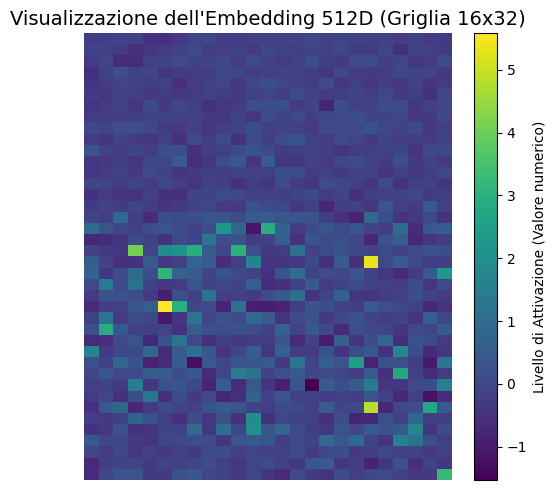

In [128]:
visualize_output_embedding(val_feat[0])

In [129]:
from sklearn.svm import SVC

svc =  SVC(kernel='linear')
svc.fit(train_feat, train_class_feat)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [130]:
from sklearn.metrics import classification_report, accuracy_score
print(classification_report(svc.predict(test_feat), test_class_feat))

              precision    recall  f1-score   support

           0       0.37      0.08      0.14       265
           1       0.35      0.40      0.37       619
           2       0.28      0.37      0.32       566
           3       0.25      0.27      0.26       422
           4       0.41      0.49      0.45       551
           5       0.32      0.43      0.37       466
           6       0.66      0.44      0.53       223
           7       0.54      0.59      0.56       410
           8       0.24      0.31      0.27       344
           9       0.54      0.58      0.56       442
          10       0.57      0.70      0.62       534
          11       0.32      0.35      0.33       386
          12       0.74      0.83      0.78       618
          13       0.80      0.82      0.81       705
          14       0.67      0.83      0.74       220
          15       0.59      0.71      0.64       175
          16       0.73      0.56      0.64       196
          17       0.62    


---
### Exercise 1.3: A Fine-tuning Baseline

In this exercise you should try to *improve* on the stable baseline given by the feature extraction + SVM (or whatever) classifier you produced in the previous lecture. To do this, you should *fine-tune* the ResNet-18 (or whatever model you chose) to solve the new classification task.

To do this, you could proceed by:
1. Loading the ResNet-18 (or whatever) model and replacing the final FC layer (the classifier) with a *new* classifier. This could be a single Linear layer, or could be an MLP.
2. Training the resulting model on the GTSRB dataset for a few epochs.
3. Evaluating the resulting performance.

Some things you should probably consider (especially thinking about the *next* exercise):
+ You should be monitoring not only the loss on the training set, but also a *validation* loss on an *independent* validation set. Split the training set into two datasets: one with, say, 80% of the original training samples, and another with the remaining 20%. You can use this smaller set to monitor performance and check for *overfitting*.
+ Maybe the best strategy is to not fine-tune *all* layers, but only the last few. Think about *selectively* fine-tuning layers of the network.
+ Maybe a *single* linear layer isn't the best option for the classifier. Think about using an MLP instead.

In [131]:
def train_epoch(model, dl, opt, criterion, device='cpu'):
    model.train()
    losses = []
    for (xs,ys) in dl:
        xs = xs.to(device)
        ys = ys.to(device)
        opt.zero_grad()
        logits = model(xs)
        loss = criterion(logits, ys)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return np.mean(losses)

def validation_epoch(model,dl,opt,criterion, device='cpu'):
    model.eval()
    losses=[]
    cross_entropy = nn.CrossEntropyLoss()
    with torch.no_grad():
        for (xs,ys) in dl:
            xs = xs.to(device)
            ys = ys.to(device)
            logits=model(xs)
            loss = criterion(logits,ys)
            losses.append(loss.item())
    return np.mean(losses)    

def evaluate_model(model, dl, device='cpu'):
    model.eval()
    predictions = []
    gts = []
    with torch.no_grad():
        for (xs,ys) in tqdm(dl, desc='Evaluating', leave= False):
            xs = xs.to(device)
            preds = torch.argmax(model(xs), dim=1)
            gts.append(ys)
            predictions.append(preds.detach().cpu().numpy())
    
        return accuracy_score(np.hstack(gts), np.hstack(predictions)) ,classification_report(np.hstack(gts), np.hstack(predictions), zero_division=0,digits=3)
               

def count_parameters(model):
    return np.sum([p.numel() for p in model.parameters()])
    

def finetuning_a_model(model, dl_train, dl_val, dl_test, config, device='cpu'): 
    wandb.init(
        project="Traffic_Signs_Project", 
        name=config['run_name'], 
        config=config
    )
    early_stop_max = config['early_stop_max']
    
    #freeze all parameters of the RCNN backbone
    if config['freezing'] is True:
        for p in model.parameters():
            p.requires_grad_(False)
            
    if (config['classificator'] is None):
        model.fc = nn.Linear(2048, config['num_classes'])
    else:
        model.fc = config['classificator']
        
    model.to(device)
    
    if config['freezing'] is True:
        params_to_update = model.fc.parameters()
    else:
        params_to_update = model.parameters()
    
    opt = optim.Adam(params_to_update, lr=config['learning_rate'])
    criterion = nn.CrossEntropyLoss()
    best_model_weights= copy.deepcopy(model.state_dict())

    min_loss= np.inf
    losses_train = []
    losses_val = []

    early_stop_counter = 0
    for epoch in tqdm(range(config['epochs'])):
        
        loss_train_epoch = train_epoch(model, dl_train, opt, criterion ,device=device)
        loss_val_epoch = validation_epoch(model, dl_val, opt,criterion ,device=device)
        losses_val.append(loss_val_epoch)
        losses_train.append(loss_train_epoch)

        val_acc, _ = evaluate_model(model, dl_val, device=device)
        
        wandb.log({
            "Train/Loss": loss_train_epoch,
            "Validation/Loss": loss_val_epoch,
            "Validation/Accuracy": val_acc,
            "epoch": epoch
        })
        
        if (loss_val_epoch < min_loss):
            best_model_weights = copy.deepcopy(model.state_dict())
            min_loss = loss_val_epoch
            early_stop_counter=0
        elif early_stop_counter < early_stop_max:
             early_stop_counter += 1
             if early_stop_counter == early_stop_max:
                 break
    model.load_state_dict(best_model_weights)
    wandb.finish()
    return model

In [135]:
config = {
    "run_name": "ResNet50_Head_Linear",
    "freezing": True,
    "epochs": 10,
    "learning_rate": 0.001,
    "early_stop_max": 5,
    "num_classes": 43,
    "classificator": None,
    "optimizer": "Adam"
}

linear_model_head = get_model("resnet50", weights='DEFAULT')
print("First Experiment - ResNet50_Head_Linear with Freezing of the Backbone.`\n")
#lr_rate=0.0001 is lower in the fine tuning of all model weight
print(device)
linear_model_head = finetuning_a_model(linear_model_head,dl_train, dl_val, dl_test,config ,device)

First Experiment - ResNet50_Head_Linear with Freezing of the Backbone.`

mps


Train/Loss,▁
Validation/Accuracy,▁
Validation/Loss,▁
epoch,▁
Train/Loss,2.80069
Validation/Accuracy,0.56997
Validation/Loss,2.06087
epoch,0


  0%|          | 0/10 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/14 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/14 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/14 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/14 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/14 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/14 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/14 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/14 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/14 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/14 [00:00<?, ?it/s]

Train/Loss,█▅▃▃▂▂▂▁▁▁
Validation/Accuracy,▁▄▅▆▇▇▇███
Validation/Loss,█▅▄▃▂▂▂▁▁▁
epoch,▁▂▃▃▄▅▆▆▇█
Train/Loss,0.61458
Validation/Accuracy,0.79219
Validation/Loss,0.78802
epoch,9


In [136]:
linear_model = get_model("resnet50", weights='DEFAULT')
config['run_name'] = "ResNet50_Linear_All"
config['freezing']= False
config['learning_rate'] = 0.001
print("Second Experiment - ResNet50_Head_Linear without Freezing of the Backbone.`\n")
#lr_rate=0.0001 is lower in the fine tuning of all model weight
linear_model = finetuning_a_model(linear_model,dl_train, dl_val, dl_test, config,device)

Second Experiment - ResNet50_Head_Linear without Freezing of the Backbone.`



  0%|          | 0/10 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/14 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/14 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/14 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/14 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/14 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/14 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/14 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/14 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/14 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/14 [00:00<?, ?it/s]

Train/Loss,█▁▁▁▁▁▁▁▁▁
Validation/Accuracy,▁▅▆▇█▇██▇█
Validation/Loss,█▄▃▂▁▁▁▁▂▁
epoch,▁▂▃▃▄▅▆▆▇█
Train/Loss,0.01941
Validation/Accuracy,0.99354
Validation/Loss,0.01692
epoch,9


In [138]:
print(device)
mlp_model = get_model("resnet50", weights='DEFAULT')
config['run_name'] = "ResNet50_MLP_All"
print("Third Experiment - ResNet50_Head_MLP without Freezing of the Backbone.`\n")
#Trying with a MultiLayer Perceptron
classificator_MLP = nn.Sequential(nn.Linear(2048,516),nn.ReLU(),nn.Dropout(0.5), nn.Linear(516, 43))
config['classificator'] = classificator_MLP
mlp_model = finetuning_a_model(mlp_model,dl_train, dl_val, dl_test,config ,device)

mps
Third Experiment - ResNet50_Head_MLP without Freezing of the Backbone.`



Train/Loss,█▇▁▁
Validation/Accuracy,▁█▃▆
Validation/Loss,▆▃█▁
epoch,▁▃▆█
Train/Loss,0.05121
Validation/Accuracy,0.97282
Validation/Loss,0.09105
epoch,3


wandb-core(19186) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(19187) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(19201) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


wandb-core(19207) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  0%|          | 0/10 [00:00<?, ?it/s]

wandb-core(19215) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(19220) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(19226) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Exception ignored in: <generator object tqdm_notebook.__iter__ at 0x39103b6a0>
Traceback (most recent call last):
  File "/Users/marcodestefano/FML/miniconda3/envs/FML/lib/python3.13/site-packages/tqdm/notebook.py", line 255, in __iter__
    self.disp(bar_style='danger')
  File "/Users/marcodestefano/FML/miniconda3/envs/FML/lib/python3.13/site-packages/tqdm/notebook.py", line 139, in display
    def display(self, msg=None, pos=None,
KeyboardInterrupt: 


KeyboardInterrupt: 

wandb-core(19232) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(19244) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(19246) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(19247) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(19249) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(19252) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(19253) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(19254) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(19255) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(19259) MallocStackLogging: can't turn off malloc stack logging because 

---
---
## Exercise 2: Pipeline Consolidation

Consolidate your implementation. When building applications based asd on Deep Learning, you will inevitably need to run many, many experiments. So, it is *always* a good idea to engineer a reproducible pipeline that allows you to run (and re-run) experiments with different hyperparameters. In this exercise you should do exactly this: engineer a deep learning pipeline that encapsulates (at least) training and evaluation so that you can easily and reproducibly run multiple experiments and compare the results.

Some things to think about when engineering this pipeline:
- **Model and Loss (and maybe Optimizer) Abstraction**: An important variable in training deep models is the model (obviously), the loss (somewhat less obvious), and the optimizer (less obvious) used during training. Your pipeline should probably be able to adapt to these changing configurations.
- **Configuration management**: Instead of global variables specializing each cell, thread a configuration object through your code (or use a singleton). If you are planning to use an IDE and not this notebook for the lab, you might consider using a configuration management library like [OmegaConf](https://omegaconf.readthedocs.io/en/2.3_branch/) which will help instrument your code so that you can pass configuration overrides via command line arguments.
- **Logging**: You will invariably need to run and compare multiple experiments. Instrument your code for monitoring training. Good options are [Tensorboard](https://docs.pytorch.org/tutorials/recipes/recipes/tensorboard_with_pytorch.html) or [Weights and Biases (WandB)](https://wandb.ai/site/). My PhD students seem to overwhelmingly prefer Weights and Biases. The configuration parameters should be used to facilitate distinguishing and comparing multiple runs with multiple hyperparameters.

In [23]:
# Your code here.

my_config = {
    "model" : "resnet18",
     "classificator" : nn.Linear(512,43),
    "learning_rate": 0.0001,
    "epochs": 40,
    "freezing": False,
    "transform" : T.Compose([T.Resize(70),T.RandomCrop((64,64)),T.ToTensor(), T.Normalize(mean=[0.485,0.456, 0.406], std=[0.229,0.224,0.225])]),
    "batch_size": 1024,
    "early_stop_max": 5
}


def pipeline_experiment(config):

    model = get_model(config["model"])
    
    device= 'cuda' if torch.cuda.is_available() else "cpu"
    
    ds_train, ds_val, ds_test = init_datasets(config["transform"])
    
    dl_train, dl_val, dl_test = init_dataloader(ds_train, ds_val, ds_test, config["batch_size"])

    finetuning_a_model(model, dl_train,dl_val, dl_test, device, config["classificator"], config["epochs"], config["freezing"], config["early_stop_max"], config["learning_rate"])

    return model

/home/deste00/miniconda3/envs/FML/lib/python3.13/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(



---
---
## Exercise 3: Choose your Own Adventure

As promised, you should choose **one** of the following exercises to work. Well, at *least* one. If you want to do them all, that is also OK! 

---
### Exercise 3.1 (Easy): Improving Fine-tuning Performance

In this exercise you are asked to iterate on the fine-tuning experiment performed in Exercise 1.3 in order to squeeze the best performance possible out of the model.

What can we do:
- Use a more powerful model?
- More aggressive data augmentation?
- Selective layer training?
- Something else?

**Why choose this exercise?** To hone your skills at incrementally improving fined-tuned model performance via a sequence of (carefully monitored) experiments.

In [25]:
# Your code here.


---
### Exercise 3.2: Retrieval as Training-free Classification (a bit harder)

In this exercise you will treat the problem of classifying road signs as a type of retrieval problem. By doing so, will will avoid the need to perform extensive fine-tuning of our model and will instead count of the good *representations* provided by massively pretrained models.

How, you ask? In this exercise you should treat the training set as a *gallery* of indexed image descriptors and the test set as a set of *query* descriptors. You could proceed in this way:

1. **Implement** a generic *feature extraction* function that, given a model and a dataloader, will extract the feature representations of all images in the dataloader. You should make this function generic because you will of course want to try *multiple* pretrained backbones in order to pick the best one.
2. **Implement** a function to *query* the gallery using all extracted extracted from the test set. The results of this should be a *ranking* of all gallery images in terms of similarity with each test image. You should think carefully about how to compute this *similarity* score and how to compute it efficiently.
3. **Evaluate** the retrieval performance on each of the 43 classes in the GTSRB dataset using the similarity scores. This could be done using precision recall curves, average precision/recall, or other metrics.

Wait, this isn't a classifier... Well, no. But, if you use the above *pipeline* to select the best feature extraction pipeline, you can then implement a **Nearest-Mean Classifier (NMC)**: compute the *mean* feature representation of all training images for each class and *classify* test images based on which mean is **nearest** to it.

**Why choose this exercise?** To learn how to make the most out of pretrained feature extraction backbones, how to evaluate different types of learning systems (retrieval in this case), and to familiarize yourself with similarity-based classification which is extensively used in multimodal models like CLIP.

In [26]:
# Your code here.


---
### Exercise 3.3: *Detecting* Traffic Signs (hardest)

In this exercise you will see if you can take your pretrained *classification* backbone and turn it into a *detector*. We will need another dataset for this -- one with *full image frames* instead of cropped sign images. Luckily, this dataset is available on [Hugging Face](https://huggingface.co/datasets/keremberke/german-traffic-sign-detection) (see below for how to access it).

For this exercise, you could:
1. Start from an available Faster-RCNN model from `torchvision` and *replace* the feature extraction backbone with your ResNet fine-tuned on GTRSB.
2. This *stitched-together* network should do an OK-ish job already of detecting at least *some* traffic signs. See how it performs on some of the images from the GTRSB Detection dataset. Implement a simple function to visualize detections superimposed over the original image. Compute some detection metrics (accuracy @ IoU=0.5, for example).
3. If you're feeling ambitious, you could also *fine-tune* the resulting model to improve detection performance.

**NOTE**: The pretrained Faster-RCNN models in `torchvision` are all based on ResNet-50, so this exercise will likely be much less painful if you use a ResNet-50 from the very start.

**Also Note**: To use the **GTRSB Detection Dataset** you should use the `datasets` package from Hugging Face (version 3.X):

     # If using uv.
     uv add datasets==3

or

     # If using Anaconda
     conda install -c conda-forge datasets==3

In [12]:
ds = load_dataset(
    "keremberke/german-traffic-sign-detection", 
    name="full" 
)

In [13]:
ds_train = ds['train']
ds_test =  ds['test']
ds_val = ds ['validation']
ds_train[0]

{'image_id': 188,
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1360x800>,
 'width': 1360,
 'height': 800,
 'objects': {'id': [280],
  'area': [15129],
  'bbox': [[1089.0, 153.0, 123.0, 123.0]],
  'category': [37]}}

The dataset is already splitted in three dataset, where each one is composed by five columns:
- **image_id**: it is a identifier of the sample.
- **image**: is photo itself.
- **width**: number of pixel columns.
- **height**: number of pixel rows.
- **objects**: objects that appairs on the photo.

In [ ]:
print(f"Length: {len(ds['train'])+ len(ds['test'])+ len(ds['validation'])}\n")
ds

In [ ]:
ds_train = ds['train']
ds_test =  ds['test']
ds_val = ds ['validation']

In [ ]:
df_objects = df_train['objects'].apply(pd.Series)

df_clean = pd.concat([df_train.drop('objects', axis=1), df_objects], axis=1)

df_exploded = df_clean.explode(['id', 'area', 'bbox', 'category']).reset_index(drop=True)

df_exploded = df_exploded.dropna(subset=['category'])

distribuzione_classi = df_exploded['category'].value_counts()

distribuzione_classi.plot(kind='bar', figsize=(12, 5), title="Distribuzione delle Categorie")

In [11]:
def draw_bounding_box(image ,boxes, labels, scores, threshold=0.5):
    fig, ax = plt.subplots(figsize=(12,12))
    ax.imshow(image)

    for i,box in enumerate(boxes):
        if scores is not None and scores[i] < threshold:
            continue
        # Takes the corner Top Right and Bottom Left
        x_min, y_min, x_max, y_max = box.cpu().detach().numpy()
        width = x_max - x_min
        height = y_max - y_min
        rect = patches.Rectangle((x_min,y_min),width, height, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

        if labels is not None:
            text =f"ID: {str(labels[i].item())}"
            if scores is not None:
                text += f" Prob:{scores[i]:.2f}"

            ax.text(
                x_min, y_min - 5, text, 
                color='white', backgroundcolor='red', 
                fontsize=10, fontweight='bold'
            )
    plt.axis("off")

def calculate_iou(box_pred, box_truth):

    x_left = max(box_pred[0], box_truth[0])
    y_top = max(box_pred[1], box_truth[1])
    x_right = min(box_pred[2], box_truth[2])
    y_bottom = min(box_pred[3], box_truth[3])


    if x_right < x_left or y_bottom < y_top:
        return 0.0
    
    intersection_area = (x_right - x_left) * (y_bottom - y_top)

    box_pred_area = (box_pred[2] - box_pred[0]) * (box_pred[3] - box_pred[1])
    box_truth_area = (box_truth[2] - box_truth[0]) * (box_truth[3] - box_truth[1])

    union_area = float(box_pred_area + box_truth_area - intersection_area)

    iou = intersection_area / union_area
    
    return iou
        

In [14]:
model_vision = get_model('fasterrcnn_resnet50_fpn', weights = 'DEFAULT')
model_vision

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /Users/marcodestefano/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 160M/160M [00:08<00:00, 19.5MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

Now, we can load all the weights of the ResNet in the FasterRCNN ResNet-50-fpn.

In [142]:
linear_model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

wandb-core(19900) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(19901) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(19903) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(19906) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(19907) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(19909) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [144]:
weights = linear_model.state_dict()
report= model_vision.backbone.load_state_dict(weights, strict=False)
print("Chiavi MANCANTI nella Faster R-CNN (che PyTorch ha lasciato casuali):")
print(report.missing_keys[:5]) 

print("\nChiavi INASPETTATE dalla ResNet (che PyTorch ha scartato):")
print(report.unexpected_keys[:5])

Chiavi MANCANTI nella Faster R-CNN (che PyTorch ha lasciato casuali):
['body.conv1.weight', 'body.bn1.weight', 'body.bn1.bias', 'body.bn1.running_mean', 'body.bn1.running_var']

Chiavi INASPETTATE dalla ResNet (che PyTorch ha scartato):
['conv1.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var']


wandb-core(19929) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(19930) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(19931) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(19932) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(19934) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(19936) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(19941) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(19945) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(19947) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(19948) MallocStackLogging: can't turn off malloc stack logging because 

In [153]:
def load_all_weight(model1, model2):
    weights = model1.state_dict()

    translated_weights = {}
    
    for key, value in weights.items():
        if "fc" in key or "avgpool" in key:
            continue

        new_key= f"body.{key}"

        translated_weights[new_key] = value

    report = model2.backbone.load_state_dict(translated_weights, strict=False) 
    print(report)        

In [155]:
load_all_weight(linear_model, model_vision)

model_vision.eval()
pil_image =ds_train[0]['image']
transform = T.ToTensor()
img_tensor = transform(pil_image)
with torch.no_grad():
    output = model_vision([img_tensor])
output    

_IncompatibleKeys(missing_keys=['fpn.inner_blocks.0.0.weight', 'fpn.inner_blocks.0.0.bias', 'fpn.inner_blocks.1.0.weight', 'fpn.inner_blocks.1.0.bias', 'fpn.inner_blocks.2.0.weight', 'fpn.inner_blocks.2.0.bias', 'fpn.inner_blocks.3.0.weight', 'fpn.inner_blocks.3.0.bias', 'fpn.layer_blocks.0.0.weight', 'fpn.layer_blocks.0.0.bias', 'fpn.layer_blocks.1.0.weight', 'fpn.layer_blocks.1.0.bias', 'fpn.layer_blocks.2.0.weight', 'fpn.layer_blocks.2.0.bias', 'fpn.layer_blocks.3.0.weight', 'fpn.layer_blocks.3.0.bias'], unexpected_keys=[])


TypeError: tuple indices must be integers or slices, not str

wandb-core(20131) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


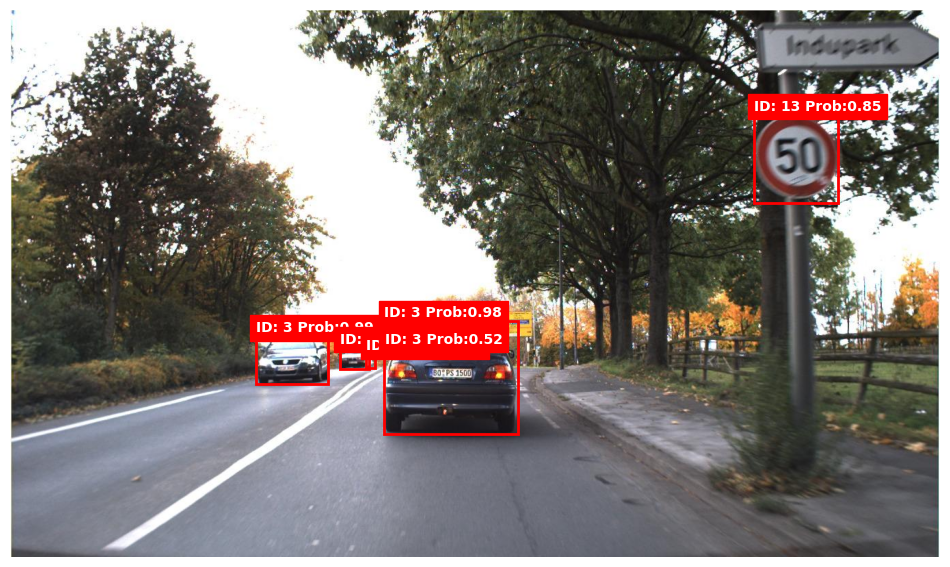

In [115]:
draw_bounding_box(pil_image, output[0]['boxes'],output[0]['labels'],output[0]['scores'])

In [119]:

def prepare_model(model_vision, dl_train, dl_val):
    # We have to cut the head off.
    # The Prediction bounding box is trained on signs and machine.
    # The number of class are 91
    in_feat = model_vision.roi_heads.cls_score.in_features
    classificator = nn.Linear(in_feat, 43)
    predictor_bbox = nn.Linear (in_feat, 43*4)
    model_vision.roi_heads.cls_score = classificator
    model_vision.roi_heads.bbox_pred = prediction
    return model_vision



def elabore_batch(batch):
    images = []
    targets = []
    
    for item in batch:
        img = F.to_tensor(item['image'].convert("RGB"))

        labels = torch.tensor(item['objects']['category'], dtype=torch.int64) + 1
        # 3. Elaboriamo le coordinate Bounding Box da [x, y, w, h] a [x1, y1, x2, y2]
        boxes = []
        for x, y, w, h in item['objects']['bbox']:
            boxes.append([x, y, x + w, y + h])
            
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
        
        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([item['image_id']]),
            "area": torch.tensor(item['objects']['area'], dtype=torch.float32),
            "iscrowd": torch.zeros((len(labels),), dtype=torch.int64)
        }
        
        images.append(img)
        targets.append(target)
    return images, targets

    
    
dataloader_train = DataLoader(
    ds_train, 
    batch_size=2, 
    shuffle=True, 
    collate_fn=elabore_batch)

dataloader_test = DataLoader(
    ds_test, 
    batch_size=2, 
    shuffle=False, 
    collate_fn=elabore_batch)

dataloader_val = DataLoader(
    ds_val, 
    batch_size=2, 
    shuffle=False, 
    collate_fn=elabore_batch)    

In [120]:
def my_iou_loss(pred_boxes, target_boxes):
    # ops.generalized_box_iou_loss fa già (1 - GIoU) internamente!
    loss = ops.generalized_box_iou_loss(pred_boxes, target_boxes, reduction="mean")
    return loss

def training_model(model, num_epochs, lr, dl_train):
    device=torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
    model.to(device)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

    model.train()
    for epoch in tqdm(range(num_epochs)):
        epoch_loss=0

        for batch_idx, (images,targets) in enumerate(dl_train):
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k,v in t.items()} for t in targets]

            optimizer.zero_grad()
            loss_dict = model(images,targets)
            
            losses = sum(loss for loss in loss_dict.values())
            

            losses.backward()
            
            optimizer.step()
            
            epoch_loss += losses.item()

            if batch_idx % 10 == 0:
                print(f"Epoca [{epoch+1}/{num_epochs}] | Batch [{batch_idx}/{len(dl_train)}] | Loss: {losses.item():.4f}")
                
        loss_media = epoch_loss / len(dl_train)
        print(f" ---> Fine Epoca {epoch+1} Completata | Loss Media: {loss_media:.4f}\n")
    
    print("Addestramento Completato!")

In [121]:
training_model(model_vision, 5, 0.005, dataloader_train)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoca [1/5] | Batch [0/192] | Loss: 0.7806
Epoca [1/5] | Batch [10/192] | Loss: 0.2894
Epoca [1/5] | Batch [20/192] | Loss: 0.3746
Epoca [1/5] | Batch [30/192] | Loss: 0.5622
Epoca [1/5] | Batch [40/192] | Loss: 0.3961
Epoca [1/5] | Batch [50/192] | Loss: 0.2050
Epoca [1/5] | Batch [60/192] | Loss: 0.3893
Epoca [1/5] | Batch [70/192] | Loss: 0.1408
Epoca [1/5] | Batch [80/192] | Loss: 0.2870
Epoca [1/5] | Batch [90/192] | Loss: 0.2448
Epoca [1/5] | Batch [100/192] | Loss: 0.1854
Epoca [1/5] | Batch [110/192] | Loss: 0.2504
Epoca [1/5] | Batch [120/192] | Loss: 0.1716
Epoca [1/5] | Batch [130/192] | Loss: 0.1770
Epoca [1/5] | Batch [140/192] | Loss: 0.2027
Epoca [1/5] | Batch [150/192] | Loss: 0.1149
Epoca [1/5] | Batch [160/192] | Loss: 0.3205
Epoca [1/5] | Batch [170/192] | Loss: 0.1383
Epoca [1/5] | Batch [180/192] | Loss: 0.1111
Epoca [1/5] | Batch [190/192] | Loss: 0.2847
 ---> Fine Epoca 1 Completata | Loss Media: 0.3092

Epoca [2/5] | Batch [0/192] | Loss: 0.2414
Epoca [2/5] | Ba

In [ ]:
import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision

def evaluate_detection_model(model, data_loader, device):

    images, targets = next(iter(data_loader))
    print("Labels:", targets[1]['labels'])
    print("Boxes:", targets[1]['boxes'])
    # 1. Inizializza la metrica
    metric = MeanAveragePrecision(iou_type="bbox")
    
    model.eval() # Fondamentale: mettiamo il modello in valutazione!
    
    with torch.no_grad():
        for images, targets in data_loader:
            images = list(img.to(device) for img in images)
            
            # 2. Otteniamo le predizioni dal modello
            # In modalità .eval(), il modello NON restituisce le loss, ma le predizioni finali!
            preds = model(images) 
            
            # Spostiamo i target sul device per sicurezza
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            # 3. Passiamo predizioni e target veri alla metrica
            metric.update(preds, targets)
            
    # 4. Calcoliamo i risultati finali
    results = metric.compute()
    
    # results è un dizionario con tante metriche. Quella principale è "map" o "map_50"
    mAP = results['map'].item()
    mAP_50 = results['map_50'].item() # Questa è la mAP considerando valida un'intersezione al 50%
    
    print(f"Mean Average Precision (mAP): {mAP:.4f}")
    print(f"mAP (IoU=0.50): {mAP_50:.4f}")
    
    return mAP_50

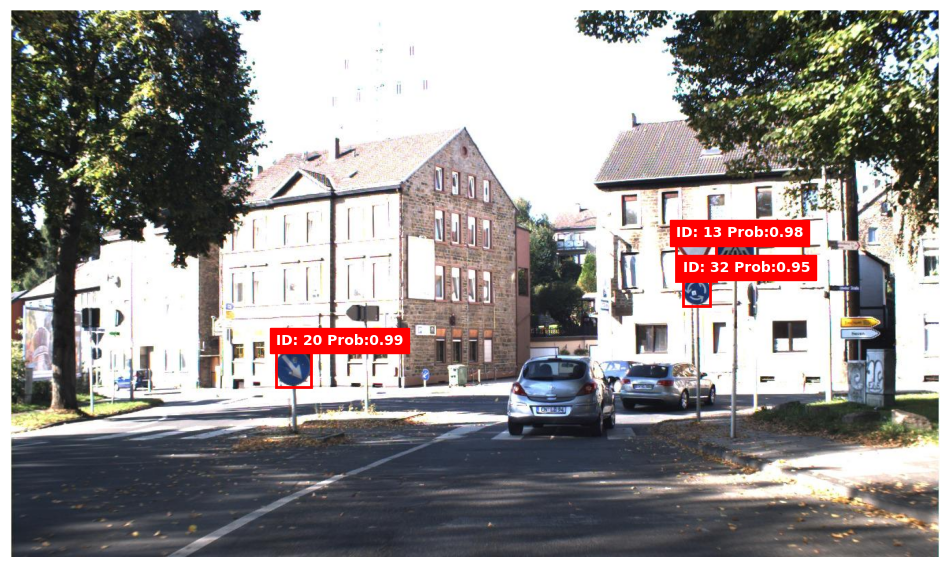

In [130]:
model_vision.to(device)
model_vision.eval()
pil_image =ds_train[2]['image']
transform = T.ToTensor()
img_tensor = transform(pil_image).to(device)
with torch.no_grad():
    output = model_vision([img_tensor])
draw_bounding_box(pil_image, output[0]['boxes'],output[0]['labels'],output[0]['scores'])

The seguent model is a vision model than it is trained with imageset very generic as background, persons, bycicles and other categories...\
So, we can train  our resnet, we will use a resnet 50 instead a 18 because the backbone is a resnet50, so the other parts of the CNN is adapted on that model.


Some things to do are:
1. Download the model resnet50.
2. Train that model with the previous dataset.
3. Modify the backbone of the Faster RCNN.
4. As output the model gave four coordinates of the bounding box.
5. With the function IoU we can have a loss and with that we can train the model.

---
---